## Laid Line extraction from reflected light images
### 0. Load relevant packages

In [10]:
#%pip install scikit-image opencv-python # ----packages needed to run the algorithm-----


In [11]:
 #packages needed to run the algorithm
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import cv2 as cv
from skimage.transform import radon, rescale, rotate
from matplotlib import cm
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

### 1. Pre-processing
Pixel size measurements can be done using Canny edge detection. As this part is dependent on details from the reflected light image, it isn't included in this code.

### 2. Patch selection
Again dependent on the image and needs to be done by the user independently.

### 3. Spectral TV decomposition
Code is available by e.g. Gilboa et al. (https://guygilboa.net.technion.ac.il/2020/10/09/spectral-total-variation-color/) in Matlab. Run the matlab code first and load the results here next. In case of obtaining the TV flow solution instead of the spectral TV decomposition directly, we have included code to derive the decomposition based on the TV flow solution. This may be more flexible when deciding how to filter the decomposition.

#### 3.1 Load Data

In [12]:
u_0 = sio.loadmat(r'Matlab_results\filtered_manuscript_4-Cut2.mat')
dec_phi= u_0['f_H'] 

### 4. Radon transform
Detect laid lines in the Radon domain. 

In [ ]:

#The matrix we obtain after applying spectral decomposition is in 3D (color) and needs to be in 2D (gray scale), so the image must be transformed into a gray scale so that radon can read it (requires a gray scale image)

image_3d= dec_phi.copy(). astype(np.float32)
image_3d_norm = (image_3d - np.min(image_3d)) / (np.max(image_3d) - np.min(image_3d))


if dec_phi.ndim > 2:
    # Is added along the last axis (spectral textures/bands)
    image_2d = np.sum (dec_phi, axis= -1)
else:
    image_2d = dec_phi

#image_3d_norm= rotate(image_3d_norm, 90) # <-----adjustable parameter----- if the image is horizontal, you have to rotate it without commenting on this line, but instead keep this line commented
#image_2d = rotate (image_2d, 90) # <-----adjustable parameter----- if the image is horizontal, you have to rotate it without commenting on this line, but instead keep this line commented

image_2d= image_2d -np.mean(image_2d)

#creates an angle vector for projections (0 to 180 degrees)
theta = np.linspace(0., 180., max(image_2d.shape), endpoint=False)

#applies the radon transform to the corrected 2d image
sinogram = radon(image_2d, theta=theta) 

#Display variables are defined for correct visualization of the "extent" in matplotlib
dx, dy = 0.5 * 180. / max(image_2d.shape), 0.5 / sinogram.shape[0] 

c:\Users\y\AppData\Local\Programs\Python\Python314\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


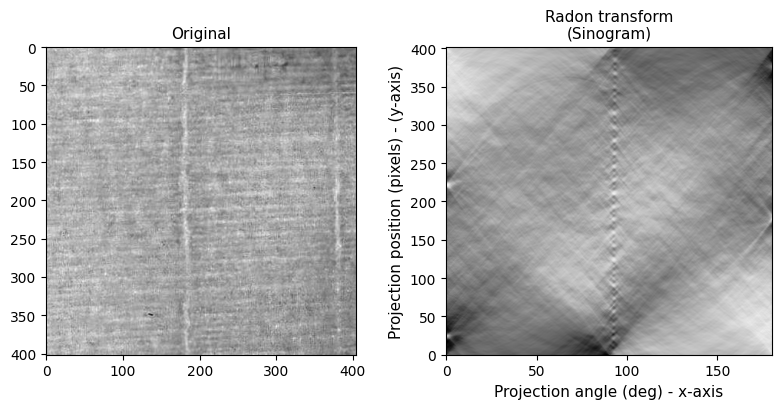

In [14]:
# Display Radon Trafo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4.2))

ax1.set_title("Original", fontsize=11)
ax1.imshow(image_2d, cmap='gray') 


ax2.set_title("Radon transform\n(Sinogram)", fontsize=11)
ax2.set_xlabel("Projection angle (deg) - x-axis", fontsize=11)
ax2.set_ylabel("Projection position (pixels) - (y-axis)", fontsize=11)
ax2.imshow(sinogram, cmap=plt.cm.Greys_r, # <---inverted gray scale
           extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy), 
           aspect='auto')

fig.tight_layout()
plt.show()

### 5. Cross-section
Take a cross-section along the relevant angle to obtain line peaks. We determine the relevant angle by finding the angle of highest magnitude:

Peak selected in the angle: 92.0


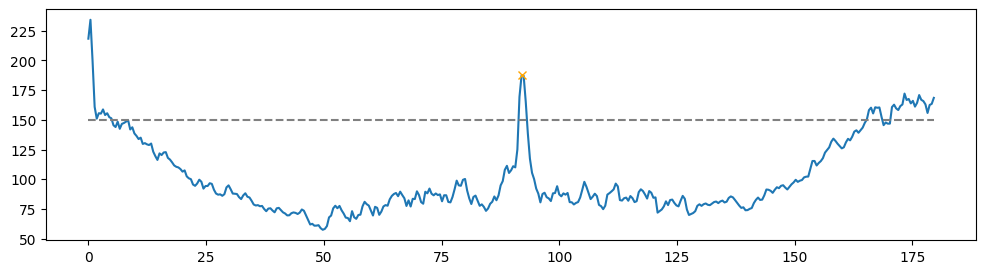

In [ ]:
# --- Cross-section or global profile of intensities--

x = [] #for the angulos(theta). where the lines are perfectly aligned with the sensor.
y = [] #for the maximum intensity in the synogram of each angle
for i in range(theta.shape[0]):
    y.append(np.max(sinogram[:,i]))
    x.append(theta[i])
y = np.array(y)
x = np.array(x)

#margin to ignore the edges ( first and last 145 pixels)
margin = 145
y_cropped = y[margin:-margin]
x_cropped = x[margin:-margin]

#Search for peaks only in the central area
height = 150
peaks_y_relatives, _ = find_peaks(y_cropped, height=height)

# Adjust the indexes to point correctly at the original array
peaks_y = peaks_y_relatives + margin


# select the best peak
if len(peaks_y) > 0:
    # looks for the index inside 'peaks_y' which has the maximum value in 'y'
    best_peak_idx = peaks_y[np.argmax(y[peaks_y])]
    
    thet = x[best_peak_idx]
    thet_idx = best_peak_idx
    print(f"Peak selected in the angle: {thet:.1f}")
else:
    print("The peak was not found at the set height")

#to visualize the results
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(x, y)

# the peaks found in the center are drawn
ax.plot(x[peaks_y], y[peaks_y], "x", color="orange") 
ax.plot(x, height*np.ones_like(x), "--", color="gray")
plt.show()

### 6. Peak detection
Locate peaks with highest magnitude, representing the laid lines based on the angle determined above. The parameter "height" determines the threshold for peak detection and is to be chosen manually. We include gaussian smoothing of the 1D signal to filter out noise.

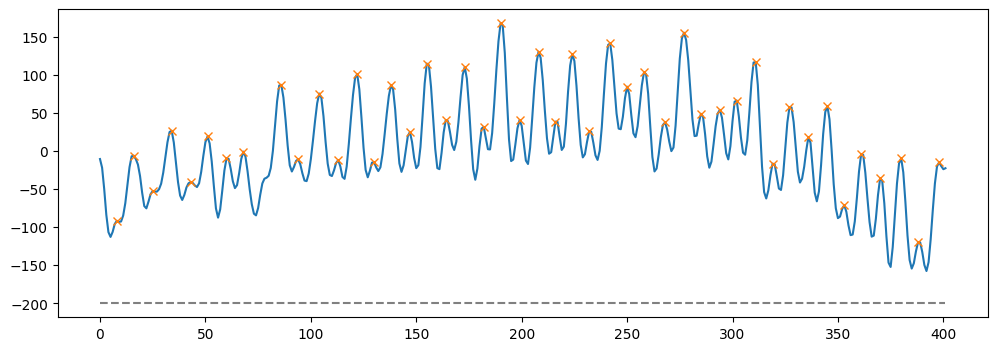

In [20]:
height = -200

std = 1 # standard deviation of the gaussian kernel for filtering
fil=1
if fil ==1:
    sino = gaussian_filter1d(sinogram[:,thet_idx],std) # smoothing of the signal
else:
    sino = sinogram[:,thet_idx]



peaks, _ = find_peaks(sino, height=height)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(sino)
ax.plot(peaks, sino[peaks], "x")
ax.plot(height*np.ones_like(sinogram[:,thet_idx]), "--", color="gray")
plt.show()

### 7. Laid Line density measurement and plotting

In [ ]:
px_mm= 0.041 #<-----adjustable parameter-----
px_cm = 10/px_mm

patch_height= dec_phi.shape[0]
patch_width= dec_phi.shape[1]

patch_pixels_size= sinogram.shape[0]

patch_pixels_size_cm =patch_pixels_size/px_cm

# Calculation of average lines per centimeter
num_avg_par_cm= len(peaks)/patch_pixels_size_cm

# Calculation of average lines for 2 centimeters
num_avg_2cm = num_avg_par_cm * 2

print(f"There are:{len(peaks)} lines in this patch")
print(f"The size patch is: {patch_height} height x {patch_width} width in pixels")
print(f"The patch size in centimeters is: {patch_pixels_size_cm:.2f} cm")
print(f"The average number of laid lines in 1 centimetres are: {num_avg_par_cm:.2f}")
print(f"The average number of laid lines in 2 centimetres are: {num_avg_2cm:.2f}")


There are:45 lines in this patch
The size patch is: 402 height x 405 width in pixels
The patch size in centimeters is: 1.65 cm
The average number of laid lines in 1 centimetres are: 27.30
The average number of laid lines in 2 centimetres are: 54.61


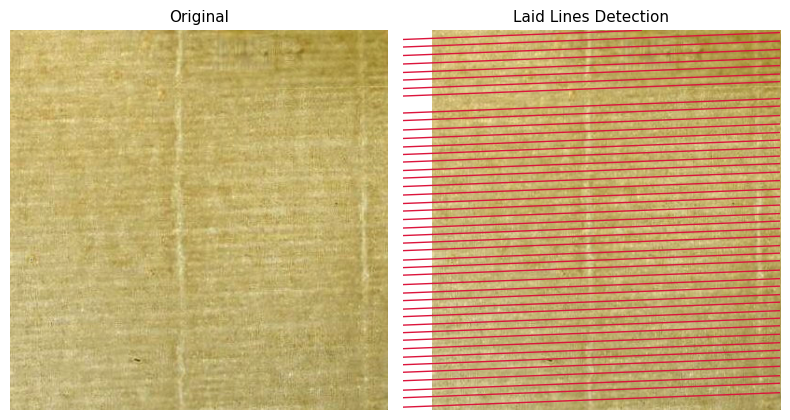

In [22]:
fig, (ax1,ax2) =plt.subplots(1,2, figsize=(8,4.3))

ax1.set_title("Original", fontsize=11)
ax1.imshow(image_3d_norm, aspect="auto" )
ax1.axis("off")

ax2.set_title("Laid Lines Detection", fontsize=11)

ax2.imshow(image_3d_norm, aspect="auto" )
ax2.axis("off")

for peak in peaks:
    (x0, y0) = peak * np.array([np.cos(np.deg2rad(thet)), np.sin(np.deg2rad(thet))])
    ax2.axline((x0, y0), slope=-np.tan(np.deg2rad(thet)+ np.pi/2),linewidth=1, color="crimson")

plt.tight_layout()
plt.show()